<a href="https://colab.research.google.com/github/kkokay07/LLM_adaptation/blob/main/Prompt_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Creator: Dr. KANAKA K. K.
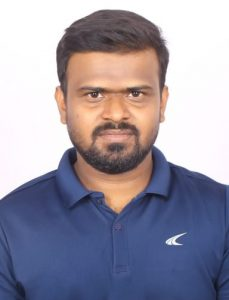

PhD, ARS  
Scientist

School of Bioinformatics and Computational Biology

ICAR-Indian Institute of Agricultural Biotechnology, Ranchi, Jharkhand.

Spy on me at :)  
[Google Scholar](https://scholar.google.com/citations?hl=en&user=0dQ7Sf8AAAAJ&view_op=list_works);    [ResearchGate](https://www.researchgate.net/profile/Kanaka-K-K/research);    [Website](https://iiab.icar.gov.in/staff/dr-kanaka-k-k/)

## 📘 Source

Natural Language Processing with Transformers  
Lewis Tunstall, Leandro von Werra, Thomas Wolf  
O’Reilly Media  

https://www.oreilly.com/library/view/natural-language-processing/9781098136789/

# 🧠 Practical 1: Prompt Engineering with LLMs
### Fundamentals of Generative AI — Hands-On Workshop

---

## 📋 What You'll Learn
1. What is Prompt Engineering and why it matters
2. Zero-shot prompting
3. Few-shot prompting
4. Chain-of-Thought (CoT) prompting
5. Role prompting
6. Prompt templates for agricultural/scientific tasks

**Model Used:** `google/flan-t5-base` (~250MB) — works perfectly on Colab Free T4 GPU

---

> ⚠️ **Before starting:** Go to `Runtime → Change runtime type → T4 GPU`

## 🔧 Step 1: Install & Import Libraries

In [ ]:
# Install required libraries
!pip install transformers accelerate sentencepiece -q
print('✅ Libraries installed!')

- transformers: A Hugging Face library providing pre-trained transformer models (e.g., BERT, GPT) and tools for training and inference in NLP, vision, and more.

- accelerate: A library by Hugging Face that simplifies and optimizes training across CPUs, GPUs, and distributed systems with minimal code changes.

- sentencepiece: A language-independent tokenization library that converts raw text into subword units (tokens) for efficient model processing.

In [ ]:
import torch
from transformers import T5ForConditionalGeneration, T5Tokenizer
import warnings
warnings.filterwarnings('ignore')

# Check GPU availability
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'🖥️  Using device: {device}')
if device == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

- torch: Core PyTorch library used for tensor operations, model building, and GPU acceleration.

- T5ForConditionalGeneration: A pre-trained transformer model from Hugging Face designed for text-to-text tasks like translation, summarization, and QA.

- T5Tokenizer: Converts raw text into token IDs that the T5 model can understand and process.

- warnings.filterwarnings('ignore'): Suppresses warning messages to keep the output clean during execution.

- torch.cuda.is_available(): Checks whether a CUDA-enabled GPU is available for computation.

- torch.cuda.get_device_name(0): Returns the name of the GPU being used.

- torch.cuda.get_device_properties(0).total_memory: Retrieves the total memory (VRAM) available on the GPU.

## 📦 Step 2: Load the Model

We use **FLAN-T5-Base** — an instruction-tuned version of T5 by Google.
It's great for following instructions, Q&A, summarization, classification, and more.

In [ ]:
print('⏳ Loading FLAN-T5-Base model... (this takes ~1 min first time)')

model_name = 'google/flan-t5-base'
tokenizer = T5Tokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name)
model = model.to(device)
model.eval()

print('✅ Model loaded successfully!')
param_count = sum(p.numel() for p in model.parameters()) / 1e6
print(f'   Parameters: {param_count:.0f}M')

- model_name = 'google/flan-t5-base': Specifies the pre-trained FLAN-T5 Base model to load from Hugging Face.

- T5Tokenizer.from_pretrained(model_name): Downloads and initializes the tokenizer corresponding to the chosen model.

- T5ForConditionalGeneration.from_pretrained(model_name): Loads the pre-trained T5 model weights for text generation tasks.

- model.to(device): Moves the model to GPU (cuda) or CPU depending on availability.

- model.eval(): Sets the model to evaluation mode (disables dropout and training-specific behavior).

- sum(p.numel() for p in model.parameters()): Computes the total number of parameters in the model.

- / 1e6: Converts parameter count into millions (M) for readability.

**f-string** = a Python string prefixed with `f` that lets you embed variables directly inside `{}`.

```python
name = "ICAR"
role = f"You are a scientist at {name}."
# result: "You are a scientist at ICAR."
```

Without f-string you'd have to do:
```python
role = "You are a scientist at " + name + "."  # messy
```

**`{}`** — the curly braces are placeholders. Python replaces `{variable}` with the variable's actual value at runtime.

```python
question = "What causes low crop yield?"

role1 = f'You are an agricultural scientist at ICAR. {question}'
# → "You are an agricultural scientist at ICAR. What causes low crop yield?"
```

You can put any Python expression inside `{}`:
```python
f"2 + 2 = {2 + 2}"        # → "2 + 2 = 4"
f"Upper: {name.upper()}"   # → "Upper: ICAR"
```

## 🛠️ Step 3: Helper Function for Generation

In [ ]:
def generate(prompt, max_new_tokens=200, num_beams=4, temperature=1.0):
    """
    Generate a response from the model given a prompt.

    Args:
        prompt: The input text/instruction
        max_new_tokens: Maximum tokens to generate
        num_beams: Beam search width (higher = better quality, slower)
        temperature: Randomness (1.0 = normal, <1 = more focused)
    """
    inputs = tokenizer(prompt, return_tensors='pt', truncation=True, max_length=512).to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=num_beams,
            early_stopping=True
        )

    result = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return result

def print_result(prompt, result, prompt_type=''):
    print(f'{'='*60}')
    if prompt_type:
        print(f'📌 Prompt Type: {prompt_type}')
    print(f'📝 PROMPT:\n{prompt}')
    print(f'🤖 MODEL OUTPUT:\n{result}')
    print(f'{'='*60}\n')

print('✅ Helper functions ready!')

- def generate(...): Defines a function to generate model responses from a given text prompt using configurable decoding parameters.

- tokenizer(prompt, return_tensors='pt', truncation=True, max_length=512): Converts input text into PyTorch tensors with truncation to fit model limits.

- .to(device): Moves input tensors to the same device (CPU/GPU) as the model.

- torch.no_grad(): Disables gradient computation to speed up inference and reduce memory usage.

- model.generate(...): Generates output tokens using decoding strategies like beam search.

- max_new_tokens: Limits how many new tokens the model can generate.

- num_beams: Controls beam search width for better quality at the cost of speed.

- early_stopping=True: Stops generation when all beams finish, improving efficiency.

- tokenizer.decode(outputs[0], skip_special_tokens=True): Converts generated token IDs back into readable text.

- def print_result(...): Defines a helper function to neatly display prompt and model output.

- print(f'{'='*60}'): Prints a separator line for better readability in output.

---
## 🎯 Part A: Zero-Shot Prompting

**Zero-shot** = asking the model to do a task with **no examples** at all.
The model relies entirely on its pre-trained knowledge.

In [ ]:
# --- Zero-Shot: Sentiment Classification ---
prompt = "Classify the sentiment of this sentence as Positive, Negative, or Neutral:\n\
Sentence: The new agricultural policy has greatly improved crop yields this season."

result = generate(prompt)
print_result(prompt, result, 'Zero-Shot Sentiment Classification')

- **`prompt`** — plain Python string; the full instruction sent to the model. `\n\` continues the string on the next line cleanly.

- **`generate(prompt)`** — calls the model (FLAN-T5) with the prompt; returns the decoded output string. Internally it runs:
  - `tokenizer(prompt)` → converts text to token IDs
  - `model.generate(**inputs)` → produces output token IDs
  - `tokenizer.decode(outputs)` → converts IDs back to text

- **`print_result(prompt, result, label)`** — helper that pretty-prints:
  - the prompt type label
  - the original prompt
  - the model's output

- **`'Zero-Shot Sentiment Classification'`** — just a display label; has no effect on the model.

**Flow:**
```
string → generate() → model inference → decoded string → print_result()
```

In [ ]:
# --- Zero-Shot: Question Answering ---
prompt = "Answer the following question:\nWhat is the role of attention mechanism in transformer models?"

result = generate(prompt, max_new_tokens=150)
print_result(prompt, result, 'Zero-Shot Question Answering')

Same structure as before, one change:

- **`prompt`** — instruction + question in one string; `\n` separates them so the model sees the task and the query clearly.

- **`generate(prompt, max_new_tokens=150)`** — same as before, but `max_new_tokens=150` allows a longer answer. Default was `200` in the helper; here it's set explicitly because QA needs more tokens than a one-word sentiment label.

- **`max_new_tokens`** — caps how many tokens the model *generates* (not including the input). Higher = longer possible output, more compute.

- **`print_result(...)`** — unchanged, just displays prompt + output.

**Rule of thumb for `max_new_tokens`:**

| Task | Typical value |
|---|---|
| Classification | 5–20 |
| Extraction | 20–50 |
| QA / explanation | 100–200 |
| Summarisation | 50–150 |

In [ ]:
# --- Zero-Shot: Text Summarization ---
text = """
Transformers are deep learning models that use self-attention mechanisms to process
sequential data. Unlike RNNs and LSTMs, transformers process all tokens in parallel,
making them much faster to train. The key innovation is the attention mechanism,
which allows the model to weigh the importance of different words when generating
an output. This architecture has led to breakthroughs in NLP with models like BERT,
GPT, and T5.
"""
prompt = f"Summarize the following text in one sentence:\n{text}"

result = generate(prompt, max_new_tokens=100)
print_result(prompt, result, 'Zero-Shot Summarization')

- **`f"...{text}"`** — f-string injects the `text` variable directly into the prompt. The model sees the instruction + the actual paragraph together.

- **`\n`** — separates instruction from content; helps the model distinguish *what to do* from *what to process*.

- **`max_new_tokens=100`** — enough for one sentence summary; shorter than QA (150) since output is constrained by the prompt itself ("in one sentence").

- **`generate()` / `print_result()`** — unchanged from before.

**Key pattern here — prompt template:**
```python
f"{instruction}\n{content}"   # instruction first, content second
```
This is the standard structure for all summarisation, translation, and classification prompts.

---
## 🎯 Part B: Few-Shot Prompting

**Few-shot** = providing a few **examples** (input→output pairs) BEFORE the actual question.  
This guides the model on what format/style of answer is expected.

📌 Key Insight: More examples = better alignment with desired output format

In [ ]:
# --- Few-Shot: Sentiment Classification (with examples) ---
prompt = """\
Classify the sentiment as Positive, Negative, or Neutral.

Sentence: The harvest was excellent this year.
Sentiment: Positive

Sentence: The drought destroyed most of the wheat crop.
Sentiment: Negative

Sentence: The research paper was published last month.
Sentiment: Neutral

Sentence: The new irrigation system has failed to deliver expected results.
Sentiment:"""

result = generate(prompt)
print_result(prompt, result, 'Few-Shot Sentiment Classification')

In [ ]:
# --- Few-Shot: Entity Extraction ---
prompt = """\
Extract the crop name from the sentence.

Sentence: Farmers in Punjab are growing a new variety of wheat.
Crop: wheat

Sentence: The paddy fields were flooded due to heavy rainfall.
Crop: paddy

Sentence: Scientists at ICAR developed a disease-resistant variety of chickpea.
Crop:"""

result = generate(prompt)
print_result(prompt, result, 'Few-Shot Entity Extraction')

In [ ]:
# --- Comparison: Zero-Shot vs Few-Shot ---
print('🔬 COMPARISON: Zero-Shot vs Few-Shot\n')

task = 'Sentence: The model overfitted on the training data.'

# Zero-shot
zs_prompt = f'Classify whether this sentence is about machine learning or agriculture.\n{task}'
zs_result = generate(zs_prompt)

# Few-shot
fs_prompt = f"""\
Classify whether this sentence is about machine learning or agriculture.

Sentence: The gradient descent algorithm converged after 100 epochs.
Category: machine learning

Sentence: The soil pH needs to be adjusted for better yield.
Category: agriculture

Sentence: The neural network has 12 transformer layers.
Category: machine learning

{task}
Category:"""
fs_result = generate(fs_prompt)

print(f'📌 Task: {task}')
print(f'\n Zero-Shot Output: {zs_result}')
print(f' Few-Shot Output:  {fs_result}')
print('\n💡 Observation: Few-shot gives a cleaner, more aligned output!')

---
## 🎯 Part C: Chain-of-Thought (CoT) Prompting

**CoT** = asking the model to **reason step by step** before giving the final answer.  
This dramatically improves performance on complex reasoning tasks.

Key phrase: *"Let's think step by step"*

In [ ]:
# --- Standard Prompting ---
prompt_standard = """\
A farmer has 120 kg of seeds. He plants 40% in the first field and 25% in the second field.
How many kg of seeds are left?"""

result_standard = generate(prompt_standard, max_new_tokens=100)
print_result(prompt_standard, result_standard, 'Standard Prompting (No CoT)')

In [ ]:
# --- Chain-of-Thought Prompting ---
prompt_cot = """\
A farmer has 120 kg of seeds. He plants 40% in the first field and 25% in the second field.
How many kg of seeds are left? Let's think step by step."""

result_cot = generate(prompt_cot, max_new_tokens=200)
print_result(prompt_cot, result_cot, 'Chain-of-Thought Prompting')

---
## 🎯 Part D: Role Prompting

**Role prompting** = telling the model to act as a specific expert.  
This shapes the tone, depth, and focus of the response.

In [ ]:
question = 'What are the main causes of low crop yield?'

# Role 1: Agricultural Scientist
role1 = f'You are an agricultural scientist at ICAR. {question}'
r1 = generate(role1, max_new_tokens=150)

# Role 2: Data Scientist
role2 = f'You are an AI/ML researcher. How would a machine learning model help predict: {question}'
r2 = generate(role2, max_new_tokens=150)

# Role 3: Farmer
role3 = f'You are an experienced farmer. Explain in simple terms: {question}'
r3 = generate(role3, max_new_tokens=150)

print('='*60)
print(f'❓ Question: {question}\n')
print(f'🔬 As Agricultural Scientist:\n{r1}\n')
print(f'💻 As Data Scientist:\n{r2}\n')
print(f'🌾 As Farmer:\n{r3}')
print('='*60)
print('\n💡 Notice how the same question gets different perspective based on role!')

---
## 🎯 Part E: Prompt Templates for Scientific Tasks

Building reusable prompt templates — useful for research workflows.

In [ ]:
# --- Reusable Prompt Templates ---

def classify_text(text, categories):
    """Template for text classification"""
    cats = ', '.join(categories)
    prompt = f'Classify the following text into one of these categories: {cats}.\nText: {text}\nCategory:'
    return generate(prompt)

def summarize(text, length='short'):
    """Template for summarization"""
    length_map = {'short': 'one sentence', 'medium': 'two sentences', 'long': 'a paragraph'}
    prompt = f'Summarize the following text in {length_map.get(length, "one sentence")}:\n{text}'
    return generate(prompt, max_new_tokens=200)

def translate_to_simple(text):
    """Template to simplify scientific text"""
    prompt = f'Explain the following scientific text in simple words for a high school student:\n{text}'
    return generate(prompt, max_new_tokens=200)

def extract_keywords(text):
    """Template for keyword extraction"""
    prompt = f'Extract the 3 most important keywords from this text, separated by commas:\n{text}'
    return generate(prompt)

print('✅ Templates defined!')

**`classify_text(text, categories)`**
- `', '.join(categories)` — converts a list `['ML', 'agriculture']` → `"ML, agriculture"` for the prompt
- Asks model to pick exactly one category from the given list

**`summarize(text, length='short')`**
- `length_map` — dictionary that maps a simple keyword (`'short'`) to a full instruction (`'one sentence'`)
- `.get(length, "one sentence")` — if unknown length is passed, defaults to `"one sentence"`
- `length='short'` — default argument; calling `summarize(text)` works without specifying length

**`translate_to_simple(text)`**
- No parameters beyond `text` — prompt is fixed
- Targets "high school student" in prompt to control output complexity

**`extract_keywords(text)`**
- Instructs model to return exactly 3 keywords separated by commas — structured output without any post-processing code

---

**Common pattern across all four:**
```python
def template(input):
    prompt = f"instruction\n{input}"   # build prompt
    return generate(prompt)            # call model, return result
```
Each function is just a **prompt builder** — the actual intelligence is in the model.

In [ ]:
# --- Test All Templates ---
sample_text = """
Transfer learning is a machine learning technique where a model trained on one task
is reused as the starting point for a model on a different, but related task.
This approach significantly reduces the training time and data required,
making it particularly useful in agricultural AI applications where labeled data is scarce.
"""

print('📄 Original Text:', sample_text)
print('-'*50)

print('🏷️  Classification:', classify_text(sample_text.strip(), ['machine learning', 'agriculture', 'physics', 'economics']))
print()
print('📝 Summary:', summarize(sample_text.strip(), 'short'))
print()
print('🧒 Simple Explanation:', translate_to_simple(sample_text.strip()))
print()
print('🔑 Keywords:', extract_keywords(sample_text.strip()))

---
## 📊 Part F: Prompting Strategies — Summary Comparison

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════╗
║           PROMPT ENGINEERING — STRATEGY SUMMARY             ║
╠══════════════════╦═══════════════════════╦═══════════════════╣
║ Strategy         ║ When to Use           ║ Example Phrase    ║
╠══════════════════╬═══════════════════════╬═══════════════════╣
║ Zero-Shot        ║ Simple, clear tasks   ║ 'Classify...'     ║
║ Few-Shot         ║ Format-sensitive tasks║ 'Example 1:...'   ║
║ Chain-of-Thought ║ Reasoning problems    ║ 'Step by step...' ║
║ Role Prompting   ║ Tone/domain control   ║ 'You are a...'    ║
║ Templates        ║ Repeatable workflows  ║ Functions/f-str   ║
╚══════════════════╩═══════════════════════╩═══════════════════╝

Key Takeaways:
  ✅ Prompts are the interface between humans and LLMs
  ✅ Better prompts = better outputs (no retraining needed)
  ✅ Few-shot > Zero-shot for format-sensitive tasks
  ✅ CoT helps on reasoning tasks
  ✅ Role prompting shifts tone and expertise
""")